# PREPARACION DE LOS DATOS

IMPORTACION DEL DATASET

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [16]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


ENTENDER LOS DATOS:
- Saber el objetivo de los datos (identificar si un cliente de ciertas caracteristicas se quedaria en el banco)

LIMPIEZA DE DATASET:
- Eliminar columnas innecesarias(irrelevantes para la variable objetivo)
- Eliminar valores nulos
- Modificar variables categoricas a numericas
- Escalar valores muy elevados 
- Extraer la variable objetivo (exited)

In [17]:
dataset = dataset.drop_duplicates() # elimino duplicados
dataset = dataset.dropna() # elimino valores nulos

datos_x = dataset.drop(columns= ['RowNumber','CustomerId','Surname','Exited']) # elimino columnas irrelevantes
datos_x = pd.get_dummies(datos_x, dtype=int) # Modificar variables categoricas a numericas
datos_x = StandardScaler().fit_transform(datos_x) # Escalar valores para estar en rango mas corto

datos_y = dataset.Exited # extraigo la variable objetivo 
print(datos_x)

[[-0.32622142  0.29351742 -1.04175968 ... -0.57380915  1.09598752
  -1.09598752]
 [-0.44003595  0.19816383 -1.38753759 ...  1.74273971  1.09598752
  -1.09598752]
 [-1.53679418  0.29351742  1.03290776 ... -0.57380915  1.09598752
  -1.09598752]
 ...
 [ 0.60498839 -0.27860412  0.68712986 ... -0.57380915  1.09598752
  -1.09598752]
 [ 1.25683526  0.29351742 -0.69598177 ... -0.57380915 -0.91241915
   0.91241915]
 [ 1.46377078 -1.04143285 -0.35020386 ... -0.57380915  1.09598752
  -1.09598752]]


SEPARACION DE DATOS TRAIN-TEST

In [18]:
datos_x.shape # entender la forma de los datos 10mil muestras y 13 caracteristicas

(10000, 13)

In [19]:
x_train,x_test,y_train,y_test = train_test_split(datos_x,datos_y,test_size=0.2,train_size=0.8,random_state=2)

In [20]:
print("x train {}, x test {}, y train {}, y test {}".format(x_train.shape,x_test.shape,y_train.shape,y_test.shape))

x train (8000, 13), x test (2000, 13), y train (8000,), y test (2000,)


In [21]:
n_entradas = x_train.shape[1] # variable para la red neuronal
print(n_entradas)

13


CONVERTIR LOS DATOS EN TENSORES PARA PYTORCH

In [22]:
t_x_train = torch.from_numpy(x_train).float().to('cpu') # podria ser 'cuda' para meter el tensor en la gpu
t_x_test = torch.from_numpy(x_test).float().to('cpu')

t_y_train = torch.from_numpy(y_train.to_numpy()).float().to('cpu')
t_y_test = torch.from_numpy(y_test.to_numpy()).float().to('cpu')

# hacer un reshape para que las dimensiones pasen de (n) a (n,1)
t_y_train = t_y_train[:,None]
t_y_test = t_y_test[:,None]


SEPARAR EL DATAFRAME EN DATASETS

In [23]:
test = TensorDataset(t_x_test,t_y_test)
train = TensorDataset(t_x_train,t_y_train)
print(test[0])

(tensor([ 0.8326, -0.0879,  1.7245,  0.7569,  0.8077,  0.6461, -1.0307,  1.2390,
         0.9972, -0.5787, -0.5738,  1.0960, -1.0960]), tensor([1.]))


# RED NEURONAL

Definir la estructura de nuestra red
-3 capas ocultas lineares

In [24]:
class Red(nn.Module):
    def __init__(self,n_entradas):
        super().__init__()
        self.linear1 = nn.Linear(n_entradas,15)
        self.linear2 = nn.Linear(15,8)
        self.linear3 = nn.Linear(8,1)

    def forward(self,inputs):
        pred_1 = torch.sigmoid(input=self.linear1(inputs))
        pred_2 = torch.sigmoid(input=self.linear2(pred_1))
        pred_f = torch.sigmoid(input=self.linear3(pred_2))
        return pred_f


Definir los hiperparametros 

In [25]:
lr = 0.001
epochs = 2000
estatus_print = 100

Generar los objetos
- Modelo
- Optimizador
- Funcion de perdida
- historico

In [26]:
model = Red(n_entradas=n_entradas)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.BCELoss()
historico = []

#print(f"Parametros del modelo {list(model.parameters())}")
print(f"Arquitectura del model {model}")

Arquitectura del model Red(
  (linear1): Linear(in_features=13, out_features=15, bias=True)
  (linear2): Linear(in_features=15, out_features=8, bias=True)
  (linear3): Linear(in_features=8, out_features=1, bias=True)
)


Bucle de entrenamiento
- Poner a 0 los gradientes del optimizador para la iteracion
- Saber las predicciones
- Calcular la perdida
- Calcular gradientes(loss.backward())
- Actualizar los pesos (optimizador)

In [27]:
for epoch in range(1,epochs+1):
    optimizer.zero_grad()
    y_pred = model(t_x_train)
    loss = loss_fn(input=y_pred, target=t_y_train)
    loss.backward()
    optimizer.step()


    # Print cada ciertas epoch
    if epoch % estatus_print == 0:
        print(f"Epoch: {epoch} \t Loss: {round(loss.item(),4)}")

    # Calcular el accuracy(prediccion) TESTING
    with torch.no_grad():
        y_pred = model(t_x_test)
        y_pred_class = y_pred.round()
        correct = (y_pred_class == t_y_test).sum() # Saber cuantas predicciones fueron correctas
        accuracy = 100 * correct / float(len(t_y_test))

        if epoch % estatus_print == 0:
            print(f"Accuracy: {accuracy}")

    historico.append({
        'Epoch':epoch,
        'Loss':round(loss.item(),4),
        'Accuracy':round(accuracy.item(),4),
    })

historico = pd.DataFrame(historico)
print(f"Accuracy Final: {round(accuracy.item(),4)}")
    

Epoch: 100 	 Loss: 0.5517
Accuracy: 80.8499984741211
Epoch: 200 	 Loss: 0.5062
Accuracy: 80.8499984741211
Epoch: 300 	 Loss: 0.4925
Accuracy: 80.8499984741211
Epoch: 400 	 Loss: 0.4846
Accuracy: 80.8499984741211
Epoch: 500 	 Loss: 0.4763
Accuracy: 80.8499984741211
Epoch: 600 	 Loss: 0.4666
Accuracy: 80.8499984741211
Epoch: 700 	 Loss: 0.4566
Accuracy: 80.8499984741211
Epoch: 800 	 Loss: 0.4471
Accuracy: 80.8499984741211
Epoch: 900 	 Loss: 0.4384
Accuracy: 80.8499984741211
Epoch: 1000 	 Loss: 0.431
Accuracy: 81.05000305175781
Epoch: 1100 	 Loss: 0.425
Accuracy: 81.6500015258789
Epoch: 1200 	 Loss: 0.42
Accuracy: 81.9000015258789
Epoch: 1300 	 Loss: 0.4153
Accuracy: 82.4000015258789
Epoch: 1400 	 Loss: 0.4107
Accuracy: 82.94999694824219
Epoch: 1500 	 Loss: 0.4059
Accuracy: 83.3499984741211
Epoch: 1600 	 Loss: 0.4007
Accuracy: 83.6500015258789
Epoch: 1700 	 Loss: 0.395
Accuracy: 84.0
Epoch: 1800 	 Loss: 0.389
Accuracy: 84.30000305175781
Epoch: 1900 	 Loss: 0.3828
Accuracy: 84.75
Epoch: 20

Visualizacion de las metricas

,Epoch,Loss,Accuracy
0,1,0.7049,19.15
1,2,0.7024,19.25
2,3,0.6999,20.45
3,4,0.6975,31.20
4,5,0.6950,54.45
...,...,...,...
1995,1996,0.3768,84.70
1996,1997,0.3767,84.70
1997,1998,0.3766,84.70
1998,1999,0.3766,84.70


Validacion del modelo

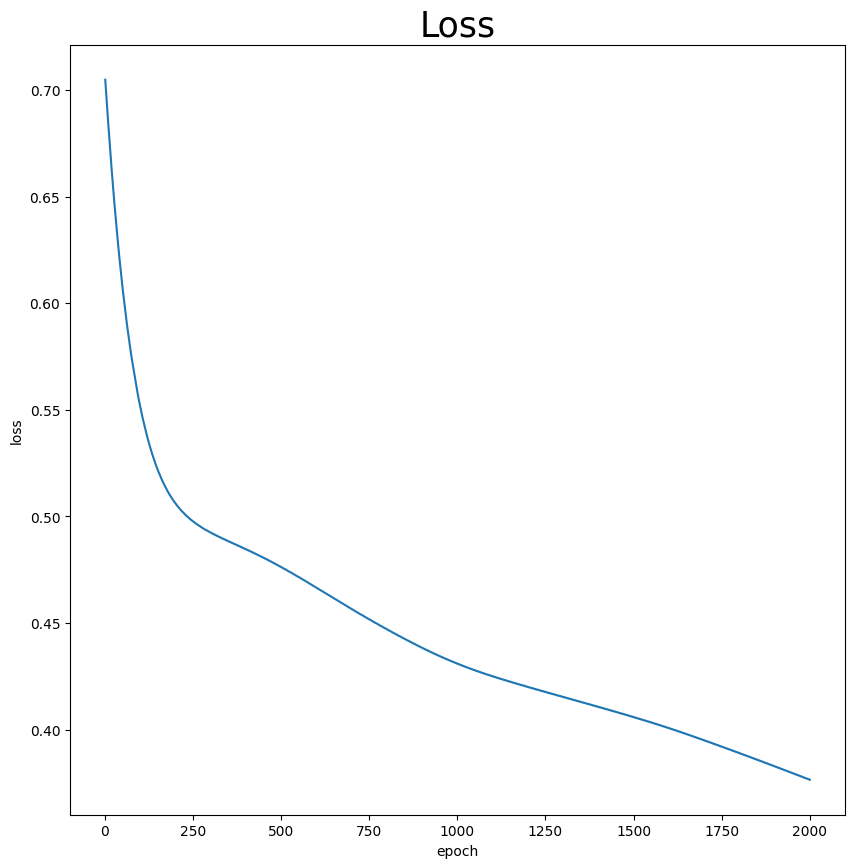

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(historico['Epoch'],historico['Loss'])
plt.title('Loss',fontsize=25)
plt.xlabel(xlabel='epoch')
plt.ylabel(ylabel='loss')
plt.show()